# Workstream C — EPT cosmology forward model

Forward map **(η, H, σ) → cosmological observables** for the everpresent-Λ /
rough-CIR scenario. This is *prerequisite infrastructure* for the eventual DESI
fit; the **MCMC itself is deferred** (per the handoff, and reinforced by
Workstream A falsifying the τ^{−d/2} conjecture — the foundations should settle
first).

What is validated here:
- (rough-)CIR Λ(t) generators reproduce CIR moments and the input Hurst H,
- the signed Λ = Λ₊−Λ₋ process has ⟨Λ⟩ ≈ 0,
- the forward model collapses onto **ΛCDM (w→−1)** in the σ→0 / η→0 limit,
- a quantified **roughness signature** distinguishing rough from smooth CIR.


In [1]:
import os, sys
import numpy as np, matplotlib.pyplot as plt
ROOT = os.getcwd()
for sub in ['ept_cosmology', 'ept_cosmology/lambda_trajectory', 'ept_cosmology/cosmology']:
    if os.path.isdir(sub): sys.path.insert(0, sub)
sys.path.insert(0, 'ept_cosmology')
import forward_model as fm
from rough_cir import simulate_rough_cir, estimate_roughness
from standard_cir import simulate_cir


## 1. Λ(t) trajectories: standard CIR vs rough CIR

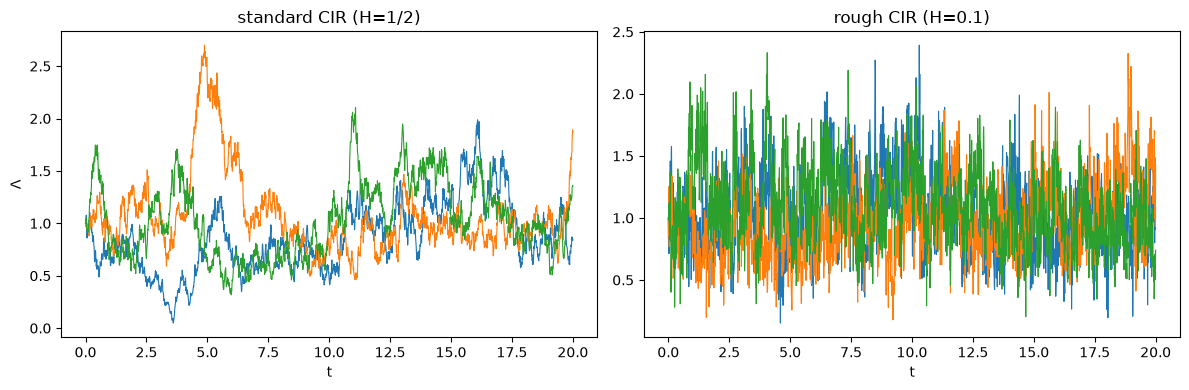

In [2]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1,2, figsize=(12,4))
t, Xs = simulate_cir(1.0,1.0,0.5,1.0, 20.0, 0.01, rng, n_paths=3)
for x in Xs: ax[0].plot(t, x, lw=0.8)
ax[0].set_title('standard CIR (H=1/2)'); ax[0].set_xlabel('t'); ax[0].set_ylabel('Λ')
t, Xr = simulate_rough_cir(1.0,1.0,0.3,1.0, 0.1, 20.0, 0.01, rng, n_paths=3)
for x in Xr: ax[1].plot(t, x, lw=0.8)
ax[1].set_title('rough CIR (H=0.1)'); ax[1].set_xlabel('t')
plt.tight_layout(); plt.show()


## 2. Roughness recovery: estimated H vs input H

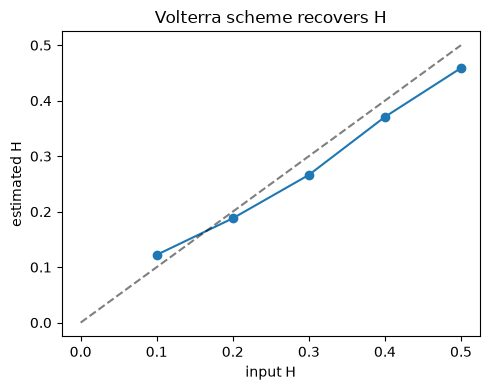

estimates: {0.1: np.float64(0.122), 0.2: np.float64(0.188), 0.3: np.float64(0.266), 0.4: np.float64(0.371), 0.5: np.float64(0.459)}


In [3]:
rng = np.random.default_rng(1)
Hin = [0.1,0.2,0.3,0.4,0.5]; Hest=[]
for H in Hin:
    _, X = simulate_rough_cir(1.0,1.0,0.3,1.0,H, 20.0,0.02, rng, n_paths=40)
    Hest.append(estimate_roughness(X, 0.02))
plt.figure(figsize=(5,4))
plt.plot(Hin, Hest, 'o-'); plt.plot([0,0.5],[0,0.5],'k--',alpha=0.5)
plt.xlabel('input H'); plt.ylabel('estimated H'); plt.title('Volterra scheme recovers H')
plt.tight_layout(); plt.show()
print('estimates:', dict(zip(Hin, np.round(Hest,3))))


## 3. w(z) trajectory ensembles for H ∈ {0.1, 0.3, 0.5}

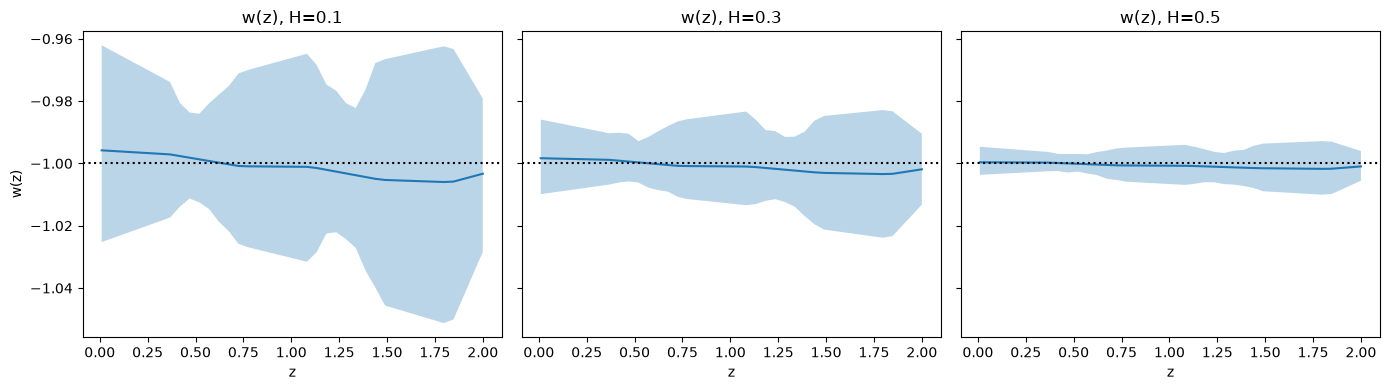

In [4]:
fig, ax = plt.subplots(1,3, figsize=(14,4), sharey=True)
for j,H in enumerate([0.1,0.3,0.5]):
    res = fm.forward(eta_cosmo=0.92, H=H, sigma_amplitude=0.06, n_traj=150, seed=5)
    z = res['z_sn']; w = res['wz']
    ax[j].fill_between(z, w['lo'], w['hi'], alpha=0.3)
    ax[j].plot(z, w['mean'])
    ax[j].axhline(-1, color='k', ls=':')
    ax[j].set_title(f'w(z), H={H}'); ax[j].set_xlabel('z')
ax[0].set_ylabel('w(z)'); plt.tight_layout(); plt.show()


## 4. ΛCDM limit (σ→0) and roughness signature

In [5]:
lim = fm.validate_lcdm_limit()
print('ΛCDM limit: max|μ-μ_ΛCDM| =', f"{lim['max_mu_diff']:.2e}",
      ' max|w+1| =', f"{lim['max_w_plus_one']:.2e}",
      ' -> w_ok:', lim['w_ok'], 'mu_ok:', lim['mu_ok'])
sig = fm.roughness_signature(eta_cosmo=0.92, sigma_amplitude=0.06)
print('roughness signature std(d^2 w/dz^2) by H:', {k: round(v,6) for k,v in sig.items()})
print('(rougher H -> larger second-difference power: the rough-vs-smooth discriminant)')


ΛCDM limit: max|μ-μ_ΛCDM| = 2.35e-08  max|w+1| = 7.16e-08  -> w_ok: True mu_ok: True


roughness signature std(d^2 w/dz^2) by H: {0.1: 0.00029, 0.3: 0.000131, 0.5: 5e-05}
(rougher H -> larger second-difference power: the rough-vs-smooth discriminant)


## 5. Distance modulus with confidence band

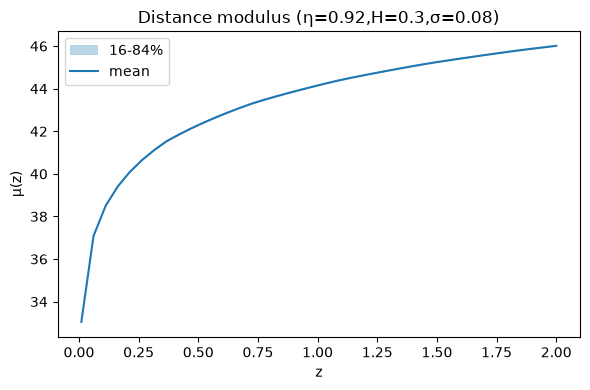

In [6]:
res = fm.forward(eta_cosmo=0.92, H=0.3, sigma_amplitude=0.08, n_traj=200, seed=7)
z = res['z_sn']; mu = res['mu']
plt.figure(figsize=(6,4))
plt.fill_between(z, mu['lo'], mu['hi'], alpha=0.3, label='16-84%')
plt.plot(z, mu['mean'], label='mean')
plt.xlabel('z'); plt.ylabel('μ(z)'); plt.legend(); plt.title('Distance modulus (η=0.92,H=0.3,σ=0.08)')
plt.tight_layout(); plt.show()


## Status

The forward map is built and validated. **Deferred** (gated on Paper 2 / Workstream A):
- the full CAMB/CLASS Boltzmann solve (`camb_interface.py` degrades gracefully to
  a fitting-formula sound horizon when CAMB is absent),
- a fast (sum-of-exponentials) rough-CIR integrator for production scale (current
  Volterra scheme is O(n²)),
- the **MCMC fit against DESI** — intentionally not run.
